In [4]:
# Task 1.1
import pandas as pd
import numpy as np
import seaborn as sns

df = sns.load_dataset("iris")
print(df.head())
print(df.shape)

# Task 1.2
df_species = df.select_dtypes(include=[np.number])
print("Mean:\n", df_species.mean())
print("Median:\n", df_species.median())
print("Mode:\n", df_species.mode().iloc[0])
print("Var:\n", df_species.var())
print("Std:\n", df_species.std())
print("Min:\n", df_species.min())
print("Max:\n", df_species.max())
print("Q1:\n", df_species.quantile(0.25))
print("Q3:\n", df_species.quantile(0.75))
print("IQR:\n", df_species.quantile(0.75) - df_species.quantile(0.25))

# Task 1.3
display(df.groupby('species').agg(['mean', 'std']))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
Mean:
 sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64
Median:
 sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64
Mode:
 sepal_length    5.0
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64
Var:
 sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64
Std:
 sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64
Min:
 sepal_length    4.

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

Nhận xét Task 1.3: Loài setosa khác biệt rõ nhất bởi có mean của sepal_length, sepal_width, petal_length, petal_width chênh lệnh lớn nhất so với 2 loài versicolor và virginica. Trong khi đó, std của setosa cũng đa số nhỏ hơn 2 loài còn lại chứng tỏ dữ liệu của setosa phân phối khá đồng đều và tập trung.

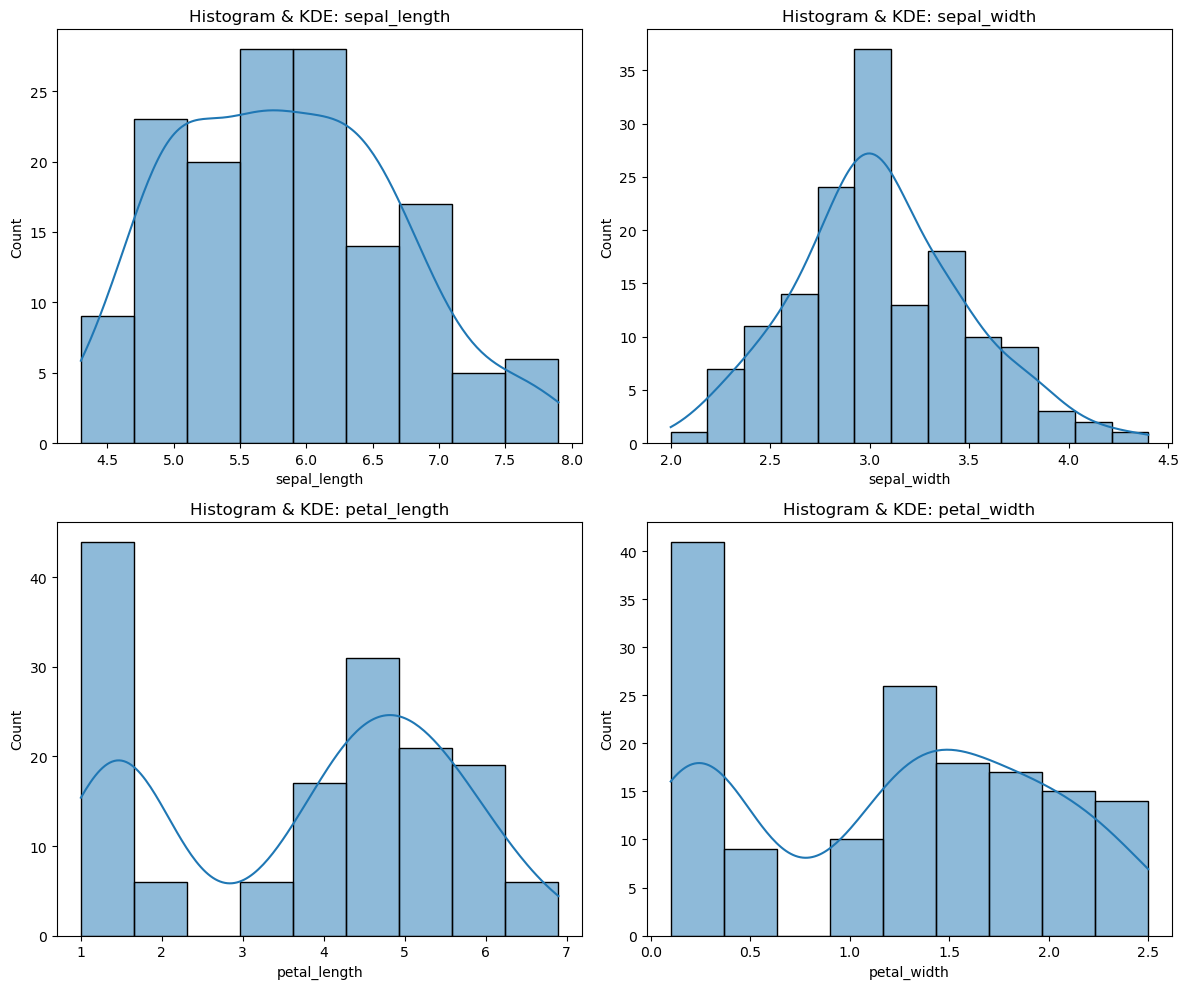

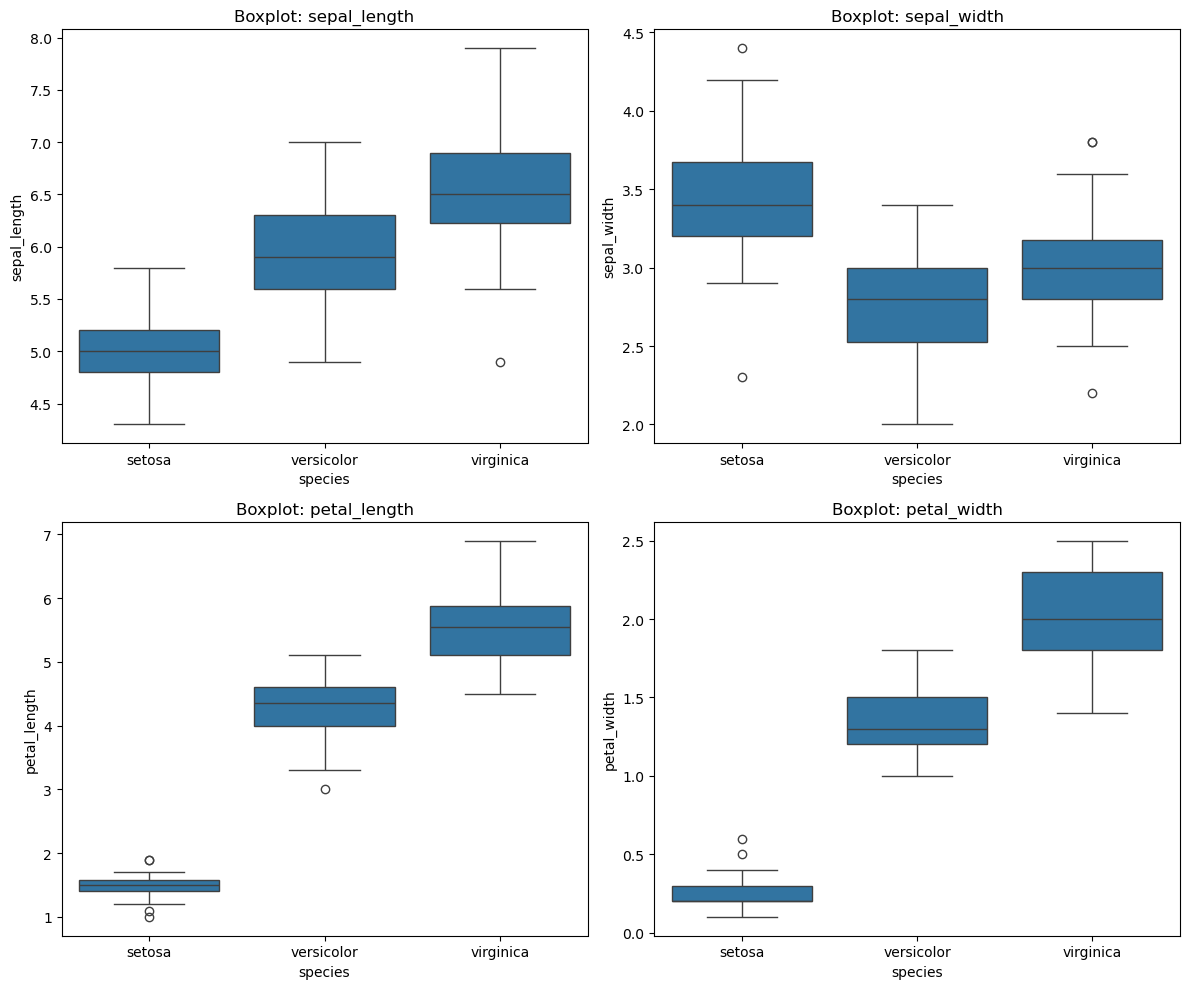

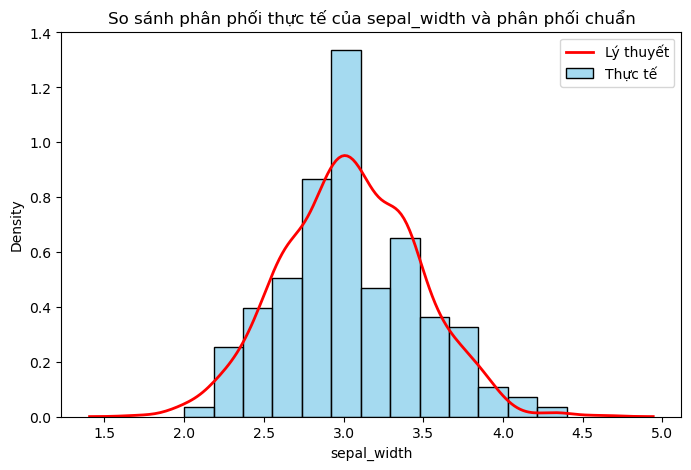

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["figure.figsize"] = (12, 10)

# Task 2.1
fig, axes = plt.subplots(2, 2)
for col, ax in zip(df_species.columns, axes.flatten()):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Histogram & KDE: {col}')
plt.tight_layout()
plt.show()

# Task 2.2
fig, axes = plt.subplots(2, 2)
for col, ax in zip(df_species.columns, axes.flatten()):
    sns.boxplot(data=df, x='species', y=col, ax=ax)
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# Task 2.3
bien = df['sepal_width']
tb_cong = bien.mean()
do_lech_chuan = bien.std()

mau_chon = np.random.normal(tb_cong, do_lech_chuan, 1000)

plt.figure(figsize=(8, 5))
# Vẽ dữ liệu thực tế
sns.histplot(bien, stat="density", color="skyblue", label="Thực tế")
# Vẽ phân phối lý thuyết
sns.kdeplot(mau_chon, color="red", linewidth=2, label="Lý thuyết")

plt.title('So sánh phân phối thực tế của sepal_width và phân phối chuẩn')
plt.legend()
plt.show()

Nhận xét Task 2.3: Mức độ khớp không hoàn toàn tương đồng nhưng có thể chấp nhận được, đối với dữ liệu tăng cao bất thường như 3.0 sepal_width hay giảm đột ngột như khoảng 3.25 sepal_width thì có sự chênh lệch lớn. Nhìn chung, độ khớp khá ổn. 

MA TRẬN HIỆP PHƯƠNG SAI


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006



MA TRẬN TƯƠNG QUAN


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


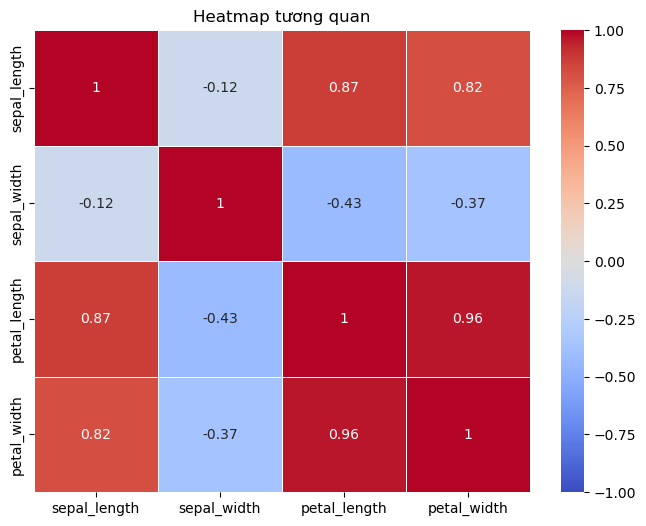

<Figure size 1000x800 with 0 Axes>

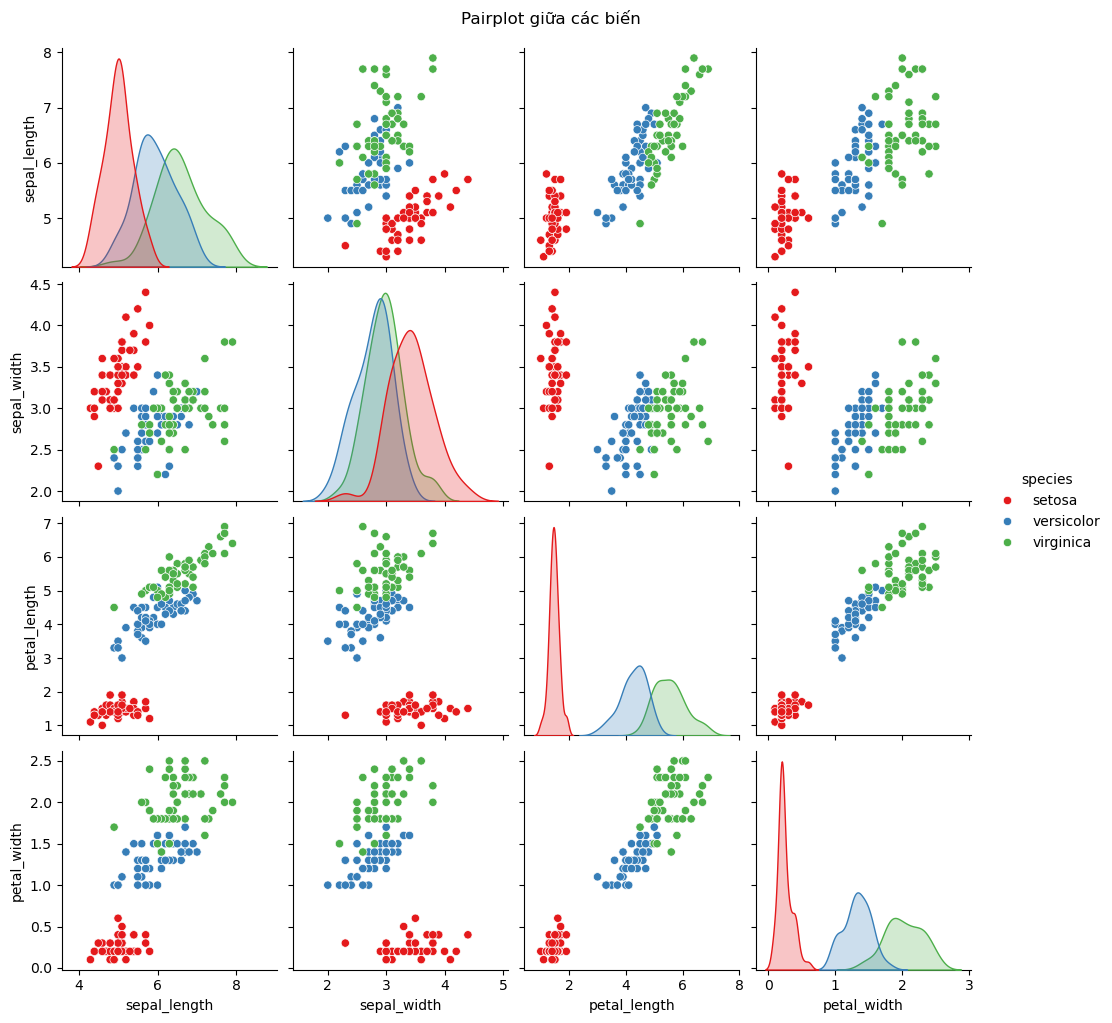

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Task 3.1
df_num = df.select_dtypes(include=[np.number])

cov_matrix = df_species.cov()
corr_matrix = df_species.corr()

print("MA TRẬN HIỆP PHƯƠNG SAI")
display(cov_matrix)
print("\nMA TRẬN TƯƠNG QUAN")
display(corr_matrix)


# Task 3.2
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap tương quan')
plt.show()


# Task 3.3
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', palette='Set1', diag_kind='kde')
plt.suptitle('Pairplot giữa các biến', y=1.02)
plt.show()

Nhận xét Task 3.3: Dựa vào heatmap ta thấy cặp quan hệ tương quan thuận theo thứ tự giảm dần là petal_length và petal_witdth (0.96), sepal_length và petal_length(0.87), sepal_length và petal_width(0.82).

Xác suất hậu nghiệm P(B|+):  0.1667


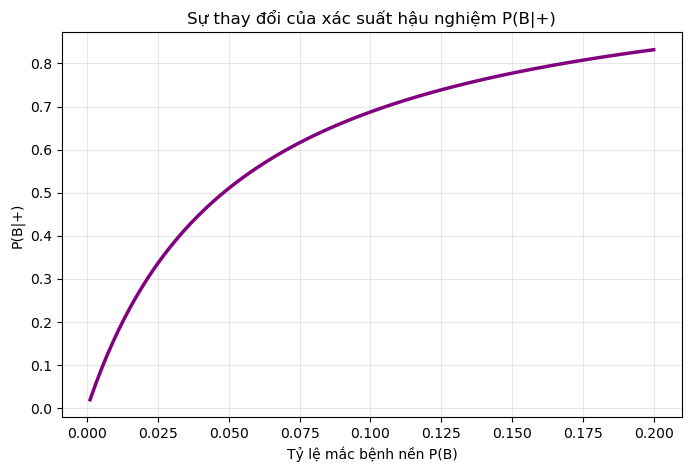

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Task 4.1
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos

print("Xác suất hậu nghiệm P(B|+): ",round(P_B_given_pos, 4))

# Task 4.2
p_B_arr = np.linspace(0.001, 0.2, 100)

p_pos_arr = P_pos_givenB * p_B_arr + P_pos_givnNB * (1 - p_B_arr)
p_B_given_pos_arr = P_pos_givenB * p_B_arr / p_pos_arr

plt.figure(figsize=(8, 5))
plt.plot(p_B_arr, p_B_given_pos_arr, color='purple', linewidth=2.5)
plt.title('Sự thay đổi của xác suất hậu nghiệm P(B|+)')
plt.xlabel('Tỷ lệ mắc bệnh nền P(B)')
plt.ylabel('P(B|+)')
plt.grid(alpha=0.3)
plt.show()

Giải thích Task 4.2: Bởi vì bệnh hiếm thì tỉ lệ người mắc sẽ thấp mà dân số thì lại đông dẫn đến khi xét nghiệm sẽ có nhiều người dương tính giả nên dù xét nghiệm có độ nhạy rất cao, xác suất mắc bệnh thực sự vẫn thấp.